# Electricity MFA – Holmen Hallsta Paper Mill, 2023

**Energy and exergy flow analysis of electricity-related flows, with uncertainty analysis.**

This notebook shows every data-processing step, from the raw numbers in the source documents to the final results. Run it top to bottom (*Kernel → Restart & Run All*). Every number in the report and the Excel workbook can be traced to a cell here.

| Step | What happens | Section |
|---|---|---|
| 1 | Extract and tag every raw number (source, year, quality class) | §1 |
| 2 | Convert everything to GWh/y | §2 |
| 3 | Resolve conflicting data | §3 |
| 4 | Fill gaps (residuals and assumptions) | §4 |
| 5 | Balance and cross-check | §5 |
| 6 | Apply exergy factors, find hotspots | §6 |
| 7 | Monte Carlo, sensitivity and scenarios | §7 |

**Scope:** electricity only · 2023 · GWh/y · Hallsta site fence · reference temperature T0 = 7 °C.

**Sources:** Holmen Paper AB, *Miljörapport 2023 Hallsta pappersbruk* (MR2023); Holmen answers to student questions, 2019 and 2025.

## How to read this notebook

**The question in one sentence:** the mill buys 1,450 GWh of electricity in 2023. *Where does every kilowatt-hour end up, and which step wastes the most useful energy?*

**The idea in plain words.** Think of the electricity bill as money in a household budget. Some goes to rent (the big refiners), some to groceries (paper machines), and a few small items. Nobody gave us the full budget, so we collect every number we can find, check them against each other, fill the holes with "whatever is left over", and make sure the books balance to zero.

**Material Flow Analysis (MFA)** is exactly that bookkeeping: draw boxes (processes), draw arrows (flows) between them, and make sure *what goes in = what comes out* for every box.

**Reading tips**
- Every section starts with **Intuition** (plain language), then the **Formula**, then the **code**.
- The code lives in two places: this notebook (data, tables, plots) and `src/hallsta_mfa/model.py` (the model itself, tested in `tests/`).
- Run it with `uv sync && uv run jupyter lab` (see the README).

### Glossary

| Term | Meaning |
|---|---|
| **GWh/y** | Gigawatt-hours per year. 1 GWh = 1,000 MWh = 1,000,000 kWh. A household uses ~5 MWh/y, so 1 GWh is about 200 households. |
| **TMP** | Thermo-Mechanical Pulp. Wood chips are ground between steam-heated steel discs. Very electricity-hungry, and the grinding turns most of that electricity into heat. |
| **PM** | Paper machine. Presses and dries the pulp into paper. The drying uses steam. |
| **Electric boiler** | A kettle on industrial scale: electricity heats water into steam. |
| **WWTP** | Waste-water treatment plant. |
| **Steam network** | The pipes that carry steam from where it is made (TMP heat recovery, boilers) to where it is used (PM drying). |
| **Residual / gap-filling** | When one flow is unknown, set it to *total minus all the known flows*. It absorbs every error, so treat it as the least certain number. |
| **Energy** | The *quantity* of energy. It is never destroyed, only moved. |
| **Exergy** | The *quality* of energy: how much of it could still do useful work. Electricity is pure exergy. Lukewarm water has almost none. |
| **T0 (dead state)** | The surroundings temperature (here 7 °C). Heat at T0 has zero exergy because it cannot drive anything. |
| **Monte Carlo** | Re-run the model thousands of times with randomly drawn inputs to see how much the answer moves. |
| **Triangular / normal / uniform** | Three shapes for "how sure am I about this input": a most-likely value with limits, a bell curve, or "anywhere in this range". |
| **P5 / P50 / P95** | The 5th, 50th (median) and 95th percentiles of the Monte Carlo results. 90% of runs fall between P5 and P95. |
| **Spearman ρ** | A number from -1 to +1 that says how strongly two things move together (by rank). |
| **Class A/B/C/D** | Data quality: A measured 2023, B recent estimate, C older or indirect, D our own assumption. |

In [1]:
# Setup. The model itself lives in src/hallsta_mfa/model.py, so the maths can be tested.
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import CoolProp.CoolProp as CP
import plotly.graph_objects as go
from IPython.display import Image, display
from scipy.stats import spearmanr
from hallsta_mfa.model import BASE, DIST, PROCS, f_sens, steam_v, run

pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
pd.set_option('display.max_colwidth', 80)
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)

## 1. Extract and tag the raw data
**Intuition.** Before calculating anything, write down every number with its *receipt*: where it came from and how much we trust it. A measured 2023 value is worth more than a 2019 email answer. Keeping this table lets us later say "this result is only as good as these inputs".

## 1. Extract and tag the raw data

I read the five documents and copied out every number that describes electricity, steam or heat. Each number keeps its **original value and unit**, the document it came from, and a **quality class**:

- **A** = measured and reported for 2023 (MR2023)
- **B** = recent Holmen estimate (2025 answers)
- **C** = older Holmen data (2019) or indirect
- **D** = engineering assumption (no data available)

Nothing is converted yet. This table is the raw inventory.

In [2]:
raw = pd.DataFrame([
 # id,            description,                               value,      unit,          source,                                 year, class
 ('E_tot',       'Total electricity use',                    1450,       'GWh/y',       'MR2023 Table 13',                       2023, 'A'),
 ('paper_t',     'Paper production',                         444494,     't/y',         'MR2023 Table 3',                        2023, 'A'),
 ('pulp_t',      'TMP pulp production',                      421883,     't/y',         'MR2023 Table 3',                        2023, 'A'),
 ('DH_MWh',      'Excess heat to Norrtälje Energi',          11877,      'MWh/y',       'MR2023 §8.3.3',                         2023, 'A'),
 ('Q_wwtp',      'Flow from WWTP to recipient',              18300,      'm3/d',        'MR2023 §5.2',                           2023, 'A'),
 ('V_total',     'Total effluent, both outlets',             7288861,    'm3/y',        'MR2023 §5.2',                           2023, 'A'),
 ('days_PM11',   'PM11 operating days',                      285.3,      'd',           'MR2023 Table 4',                        2023, 'A'),
 ('days_PM12',   'PM12 operating days',                      314,        'd',           'MR2023 Table 4',                        2023, 'A'),
 ('diesel',      'Diesel, internal transport (excluded)',    2.82,       'GWh/y',       'MR2023 Table 13',                       2023, 'A'),
 ('sh_TMP_25',   'TMP share of electricity',                 70,         '%',           'Holmen answers 2025',                   2025, 'B'),
 ('sh_PM_25',    'Paper machines share',                     15,         '%',           'Holmen answers 2025',                   2025, 'B'),
 ('sh_EB_25',    'Electric boilers share',                   10,         '%',           'Holmen answers 2025',                   2025, 'B'),
 ('sh_TMP_19',   'TMP share (3-yr avg)',                     72,         '%',           'Holmen answers 2019 (study visit)',     2019, 'C'),
 ('sh_PM_19',    'Paper machines share (3-yr avg)',          22,         '%',           'Holmen answers 2019 (study visit)',     2019, 'C'),
 ('sh_EB_19',    'Electric boilers share (3-yr avg)',        6,          '%',           'Holmen answers 2019 (study visit)',     2019, 'C'),
 ('P_wood',      'Wood handling electricity',                2.5,        'MW',          'Holmen answers 2025',                   2025, 'B'),
 ('P_bleach',    'Bleaching electricity',                    3.0,        'MW',          'Holmen answers 2025',                   2025, 'B'),
 ('P_wwtp',      'WWTP electricity',                         2.5,        'MW',          'Holmen answers 2025',                   2025, 'B'),
 ('aux_TMP',     'TMP auxiliary drives',                     150,        'kWh/t',       'Holmen answers 2025',                   2025, 'B'),
 ('SEC_norm',    'Normal TMP refining energy (upper)',       2000,       'kWh/t',       'Holmen answers 2025 (1,500–2,000)',     2025, 'B'),
 ('m_rec',       'Steam recycled from TMP',                  100,        't/h',         'Holmen answers 2025',                   2025, 'B'),
 ('y_EB',        'Steam from electric boiler',               1.5,        't/MWh',       'Holmen answers 2025',                   2025, 'B'),
 ('m_PM',        'Steam to PM drying (80–110)',              95,         't/h',         'Holmen answers 2025',                   2025, 'B'),
 ('m_wood',      'Steam to wood handling',                   1.5,        't/h',         'Holmen answers 2025',                   2025, 'B'),
 ('rec_range',   'Recovery covers 70–90% of steam need',     80,         '%',           'Holmen answers 2025',                   2025, 'B'),
 ('p_steam_g',   'Steam pressure',                           2.4,        'bar(g)',      'Holmen answers 2019',                   2019, 'B'),
 ('T_cond',      'Condensate from PM',                       90,         '°C',          'Holmen answers 2019',                   2019, 'C'),
 ('TMP3_19',     'TMP3 electricity (Aug 2019)',              46000,      'MWh/month',   'Holmen answers 2019 (compiled)',        2019, 'C'),
 ('TMP12_19',    'TMP12 electricity (Aug 2019)',             38000,      'MWh/month',   'Holmen answers 2019 (compiled)',        2019, 'C'),
 ('PM11_19',     'PM11 + bleaching (Aug 2019)',              14000,      'MWh/month',   'Holmen answers 2019 (compiled)',        2019, 'C'),
 ('PM12_19',     'PM12 + bleaching (Aug 2019)',              8000,       'MWh/month',   'Holmen answers 2019 (compiled)',        2019, 'C'),
 ('steamTMP_19', 'Net steam production TMP',                 145000,     'GJ/month',    'Holmen answers 2019 (compiled)',        2019, 'C'),
 ('steamPM_19',  'Steam use paper machines',                 155000,     'GJ/month',    'Holmen answers 2019 (compiled)',        2019, 'C'),
 ('wwtp_19',     'WWTP share of electricity',                1.25,       '%',           'Holmen answers 2019 (1–1.5%)',          2019, 'C'),
 ('T_pulp',      'Pulp temperature before bleaching',        80,         '°C',          'Holmen answers 2025',                   2025, 'C'),
 ('T_PMww',      'PM waste water temperature',               50,         '°C',          'Holmen answers 2019',                   2019, 'C'),
 ('dT_eff',      'Effluent above sea temperature',           32,         'K',           'Holmen answers 2019 (pre-2020 WWTP)',   2019, 'C'),
 ('fibre',       'Fibre content of paper (80–88%)',          84,         '%',           'Holmen answers (material group)',       2025, 'C'),
], columns=['id','description','value','unit','source','year','class']).set_index('id')
raw

,description,value,unit,source,year,class
id,,,,,,
E_tot,Total electricity use,"1,450.00",GWh/y,MR2023 Table 13,2023,A
paper_t,Paper production,"444,494.00",t/y,MR2023 Table 3,2023,A
pulp_t,TMP pulp production,"421,883.00",t/y,MR2023 Table 3,2023,A
DH_MWh,Excess heat to Norrtälje Energi,"11,877.00",MWh/y,MR2023 §8.3.3,2023,A
Q_wwtp,Flow from WWTP to recipient,"18,300.00",m3/d,MR2023 §5.2,2023,A
V_total,"Total effluent, both outlets","7,288,861.00",m3/y,MR2023 §5.2,2023,A
days_PM11,PM11 operating days,285.30,d,MR2023 Table 4,2023,A
days_PM12,PM12 operating days,314.00,d,MR2023 Table 4,2023,A
diesel,"Diesel, internal transport (excluded)",2.82,GWh/y,MR2023 Table 13,2023,A


In [3]:
raw.groupby('class').size().rename('number of raw values').to_frame()

,number of raw values
class,
A,9
B,14
C,15


## 2. Convert everything to GWh/y
**Intuition.** The sources speak in MW, tonnes of steam per hour, GJ per month, kWh per tonne and so on. To add or compare flows they must all be in the same unit. Think of converting euros, dollars and kronor to one currency before summing a budget.

**Formulas.** Power × time = energy: $E_{GWh} = P_{MW} \times h / 1000$. Steam: $E = \dot m \times h \times \Delta h / 1000$, where $\Delta h$ is the energy released by one tonne of steam when it condenses and cools.

**A worked example (wood handling).** 2.5 MW running 7,200 h = 2.5 × 7,200 / 1000 = **18 GWh/y**. The code below does this for every row.

## 2. Convert everything to GWh/y

Raw values come in eight different units. Each conversion rule is written once as a small function, so the same rule is used everywhere.

| Raw unit | Rule to GWh/y |
|---|---|
| MW (power) | MW × running hours / 1,000 |
| t/h of steam | t/h × hours × Δh / 1,000, where Δh = energy per tonne of steam |
| t steam / MWh | yield × Δh = boiler efficiency |
| GJ/month | × 12 / 3,600 |
| MWh/month | × 12 / 1,000 |
| % of electricity | % × 1,450 GWh |
| m³ of warm water | m³ × ρcp × (T − T0) / 3.6·10⁶ |
| kWh/t | × tonnes / 10⁶ |

**Running hours.** The paper machines ran 285 and 314 days, about 300 days on average. That gives **7,200 production hours** (class D). The WWTP ran all 365 days (8,760 h).

**Steam energy, Δh.** Steam at 2.4 bar(g), i.e. 3.4 bar abs, condenses and returns as 90 °C water. Steam tables (CoolProp, IAPWS) give the enthalpy drop:

In [4]:
T0 = 7.0                                   # °C, reference / dead state
h_prod, h_wwtp = 7200, 8760                # h/y
p_abs = (raw.loc['p_steam_g','value'] + 1.0) * 1e5   # Pa  (2.4 bar(g) -> 3.4 bar abs)

def steam(p, T_cond, T0):
    # enthalpy drop (MWh/t) and exergy factor of steam condensing to T_cond
    hg = CP.PropsSI('H','P',p,'Q',1,'Water'); sg = CP.PropsSI('S','P',p,'Q',1,'Water')
    hf = CP.PropsSI('H','T',T_cond+273.15,'P',p,'Water'); sf = CP.PropsSI('S','T',T_cond+273.15,'P',p,'Water')
    dh = hg - hf
    return dh/3.6e6, 1 - (T0+273.15)*(sg-sf)/dh

dh, fx_steam = steam(p_abs, raw.loc['T_cond','value'], T0)
Tsat = CP.PropsSI('T','P',p_abs,'Q',1,'Water') - 273.15
print(f'Saturation temperature at 3.4 bar abs: {Tsat:.1f} °C (Holmen: ~138 °C)')
print(f'Δh = {dh:.3f} MWh per tonne of steam')
print(f'Exergy factor of this steam = {fx_steam:.3f}')

Saturation temperature at 3.4 bar abs: 137.8 °C (Holmen: ~138 °C)
Δh = 0.654 MWh per tonne of steam
Exergy factor of this steam = 0.315


In [5]:
# conversion rules
MW_to_GWh    = lambda MW, hours: MW * hours / 1000
steam_to_GWh = lambda t_per_h, hours: t_per_h * hours * dh / 1000
GJm_to_GWh   = lambda GJ_month: GJ_month * 12 / 3600
MWhm_to_GWh  = lambda MWh_month: MWh_month * 12 / 1000
water_to_GWh = lambda m3, T, cpv=4.17: m3 * cpv * (T - T0) / 3.6e6

E = raw.loc['E_tot','value']
conv = pd.DataFrame([
 ('Wood handling',        '2.5 MW',             'MW × 7,200 h',            MW_to_GWh(2.5, h_prod)),
 ('Bleaching',            '3 MW',               'MW × 7,200 h',            MW_to_GWh(3.0, h_prod)),
 ('WWTP',                 '2.5 MW',             'MW × 8,760 h',            MW_to_GWh(2.5, h_wwtp)),
 ('TMP auxiliaries',      '150 kWh/t',          'kWh/t × 421,883 t',       150 * raw.loc['pulp_t','value'] / 1e6),
 ('Recovered TMP steam',  '100 t/h',            't/h × 7,200 h × Δh',      steam_to_GWh(100, h_prod)),
 ('PM drying steam',      '95 t/h',             't/h × 7,200 h × Δh',      steam_to_GWh(95, h_prod)),
 ('Wood handling steam',  '1.5 t/h',            't/h × 7,200 h × Δh',      steam_to_GWh(1.5, h_prod)),
 ('District heat',        '11,877 MWh',         '/ 1,000',                 raw.loc['DH_MWh','value'] / 1000),
 ('TMP (2019 check)',     '46,000 + 38,000 MWh/month', '× 12 / 1,000',     MWhm_to_GWh(46000 + 38000)),
 ('TMP steam (2019 check)', '145,000 GJ/month', '× 12 / 3,600',            GJm_to_GWh(145000)),
 ('PM steam (2019 check)',  '155,000 GJ/month', '× 12 / 3,600',            GJm_to_GWh(155000)),
], columns=['flow','raw value','conversion','GWh/y'])
conv

,flow,raw value,conversion,GWh/y
0,Wood handling,2.5 MW,"MW × 7,200 h",18.00
1,Bleaching,3 MW,"MW × 7,200 h",21.60
2,WWTP,2.5 MW,"MW × 8,760 h",21.90
3,TMP auxiliaries,150 kWh/t,"kWh/t × 421,883 t",63.28
4,Recovered TMP steam,100 t/h,"t/h × 7,200 h × Δh",470.68
5,PM drying steam,95 t/h,"t/h × 7,200 h × Δh",447.14
6,Wood handling steam,1.5 t/h,"t/h × 7,200 h × Δh",7.06
7,District heat,"11,877 MWh","/ 1,000",11.88
8,TMP (2019 check),"46,000 + 38,000 MWh/month","× 12 / 1,000","1,008.00"
9,TMP steam (2019 check),"145,000 GJ/month","× 12 / 3,600",483.33


## 3. Resolve conflicting data
**Intuition.** Two sources disagree, like two friends giving different split-the-bill percentages. We pick one as the *baseline*, say why, and keep the other to test later (Step 7e), so the choice is visible and not hidden.

## 3. Resolve conflicting data

**Conflict 1: two different electricity splits.** Holmen gave one split in 2019 and another in 2025. They differ by up to 7 percentage points.

In [6]:
split = pd.DataFrame({'2019 answer (3-yr avg)': [72, 22, 6, 0], '2025 answer': [70, 15, 10, 5]},
                     index=['TMP', 'Paper machines incl. bleaching', 'Electric boilers', 'Other users'])
split['difference (pp)'] = split['2025 answer'] - split['2019 answer (3-yr avg)']
split

,2019 answer (3-yr avg),2025 answer,difference (pp)
TMP,72,70,-2
Paper machines incl. bleaching,22,15,-7
Electric boilers,6,10,4
Other users,0,5,5


**Decision:** the 2025 split is the **baseline**. It is closer to 2023, it was given with the annual total (~1.5 TWh), and it includes an "other" bucket for WWTP, pumps and wood handling. The 2019 split is not discarded. It sets the outer ends of the uncertainty ranges in §7 and becomes scenario S1.

**Conflict 2: is the pulp tonnage air-dry or bone-dry?** This matters for kWh per tonne. A fibre balance settles it: the fibre in the paper must roughly equal the dry fibre in the pulp.

In [7]:
paper, pulp = raw.loc['paper_t','value'], raw.loc['pulp_t','value']
fibre_in_paper = paper * raw.loc['fibre','value'] / 100
for basis, dry in [('air-dry (90% dry)', 0.90), ('bone-dry (100% dry)', 1.00)]:
    dry_fibre = pulp * dry
    print(f'{basis:20s}: dry fibre in pulp {dry_fibre:,.0f} t vs fibre in paper {fibre_in_paper:,.0f} t -> difference {dry_fibre/fibre_in_paper-1:+.1%}')
print('Fibre losses are only ~2–3%, so the tonnage is air-dry (ADT).')

air-dry (90% dry)   : dry fibre in pulp 379,695 t vs fibre in paper 373,375 t -> difference +1.7%
bone-dry (100% dry) : dry fibre in pulp 421,883 t vs fibre in paper 373,375 t -> difference +13.0%
Fibre losses are only ~2–3%, so the tonnage is air-dry (ADT).


## 4–5. Fill the gaps and build the balance
**Intuition.** Three numbers nobody measured are set to "what is left over" (the *gaps*): utilities and other electricity, steam to hot water and venting, and heat to air. Everything else is built from inputs. Because the leftovers absorb all errors, the books balance **by construction**; the checks in 5b are what tell us whether the result is believable.

**The model is one function**, `run(params)`, in `src/hallsta_mfa/model.py`. It takes a dictionary of inputs and returns every flow. The same function is used for the base case, the scenarios and 10,000 Monte Carlo runs. It has three layers:

| Layer | Question | Main formula | Gap (residual) |
|---|---|---|---|
| 1. Electricity end uses | Where does the 1,450 GWh go? | share × total, or power × hours | Utilities & other = the 5% bucket minus the named items |
| 2. Steam loop | Where does steam come from and go? | tonnes/h × hours × Δh | Steam to hot water/venting = supply − PM − wood − losses |
| 3. Final sinks | Where does the energy finally end up? | volume × cp × (T − T_ref) | Heat to air = total in − water − district heat |

**Formula for heat in water:** $Q = V \cdot \rho c_p \cdot (T - T_{ref})$ (volume × heat capacity × temperature rise above the reference). In the model, cp is given per volume (4.17 MJ/m³K) and divided by 3.6·10⁶ to get MWh.

In [8]:
# Look at the inputs of the model. Every number here is traced to section 1.
pd.Series(BASE, name='base value').to_frame()

,base value
E_tot,"1,450.00"
paper_t,"444,494.00"
pulp_t,"421,883.00"
DH_export,11.88
V_wwtp,"6,679,500.00"
V_ff,"609,361.00"
sh_TMP,0.70
sh_PM,0.15
sh_EB,0.10
sh_OTH,0.05


In [9]:
b = run(BASE)
# Worked example by hand, same result as the function: the TMP plant gets 70 % of 1,450 GWh.
print('TMP electricity by hand :', 1450 * 0.70, 'GWh')
print('TMP electricity, model  :', round(b['el_TMP'], 3), 'GWh')
print('Steam energy per tonne (dh):', round(b['dh'], 3), 'MWh/t')
print('Base case electricity check:', round(b['el_TMP']+b['el_PM']+b['el_bleach']+b['el_EB']+b['el_wood']+b['el_wwtp']+b['el_util']+b['el_dist'], 6), 'GWh (must equal 1,450)')

TMP electricity by hand : 1014.9999999999999 GWh
TMP electricity, model  : 1015.0 GWh
Steam energy per tonne (dh): 0.654 MWh/t
Base case electricity check: 1450.0 GWh (must equal 1,450)


### Layer 1: where the electricity goes
The biggest consumer should be the TMP plant. Percentages must add up to 100%.

In [10]:
L1 = pd.DataFrame({'GWh/y': [b['el_TMP_ref'], b['el_TMP_aux'], b['el_PM'], b['el_EB'], b['el_wwtp'], b['el_bleach'],
                             b['el_util'], b['el_wood'], b['el_dist']]},
                  index=['TMP refiners','TMP auxiliary drives','Paper machines','Electric boilers','WWTP','Bleaching',
                         'Utilities & other (residual)','Wood handling','Internal grid losses'])
L1['share'] = (L1['GWh/y']/E).map('{:.1%}'.format)
L1.loc['TOTAL'] = [L1['GWh/y'].sum(), f"{L1['GWh/y'].sum()/E:.0%}"]
L1

,GWh/y,share
TMP refiners,951.72,65.6%
TMP auxiliary drives,63.28,4.4%
Paper machines,195.90,13.5%
Electric boilers,145.00,10.0%
WWTP,21.90,1.5%
Bleaching,21.60,1.5%
Utilities & other (residual),18.10,1.2%
Wood handling,18.00,1.2%
Internal grid losses,14.50,1.0%
TOTAL,"1,450.00",100%


### Layer 2: the steam loop
Steam comes from two places: heat recovered from the TMP refiners (free, a by-product) and electric boilers (costs electricity). It goes to paper drying, wood handling, pipe losses, and the leftover.

In [11]:
L2 = pd.Series({'Recovered TMP steam': b['st_rec'], 'Electric-boiler steam': b['st_EB'], '= Steam supply': b['st_supply'],
                'to PM drying': b['st_PM'], 'to wood handling': b['st_wood'], 'network losses (4%)': b['st_loss'],
                'to hot water, heating, venting (residual)': b['st_HW']}, name='GWh/y').to_frame()
L2

,GWh/y
Recovered TMP steam,470.68
Electric-boiler steam,142.18
= Steam supply,612.86
to PM drying,447.14
to wood handling,7.06
network losses (4%),24.51
"to hot water, heating, venting (residual)",134.14


In [12]:
print(f"Electric boiler efficiency : {b['eff_EB']:.1%}   (1.5 t/MWh × {b['dh']:.3f} MWh/t)")
print(f"TMP heat recovered as steam: {b['TMP_rec_eff']:.1%} of TMP electricity")
print(f"Share of steam from TMP    : {b['rec_ratio']:.1%}")

Electric boiler efficiency : 98.1%   (1.5 t/MWh × 0.654 MWh/t)
TMP heat recovered as steam: 46.4% of TMP electricity
Share of steam from TMP    : 76.8%


### Layer 3: final sinks
All the electricity ends as heat. This shows where that heat finally goes: to water, to the district heating network (useful), or to air.

In [13]:
L3 = pd.Series({'Heat to water (effluent)': b['sink_water'], 'District heating export': b['sink_DH'],
                'Heat to air (residual)': b['sink_air']}, name='GWh/y').to_frame()
L3['share'] = (L3['GWh/y']/E).map('{:.1%}'.format)
L3

,GWh/y,share
Heat to water (effluent),232.87,16.1%
District heating export,11.88,0.8%
Heat to air (residual),"1,205.25",83.1%


## 5b. Balance checks and independent cross-checks
**Intuition.** Two different tests. A **balance check** is "does the arithmetic add up?" It must be exactly 0 or we have a bug. A **cross-check** compares our result with a number we did *not* use to build the model. If they roughly agree, the model is believable.

In [14]:
pool = (b['TMP_waste'] + b['loss_EB'] + b['st_loss'] + b['PM_waste'] + b['el_bleach'] + b['el_wwtp'] + b['el_wood'] +
        b['st_wood'] + b['el_util'] + b['el_dist'] + b['st_HW'] - b['sink_DH'])
checks = pd.Series({
  'Layer 1: E − sum of end uses': E - (b['el_TMP']+b['el_PM']+b['el_bleach']+b['el_EB']+b['el_wood']+b['el_wwtp']+b['el_util']+b['el_dist']),
  'Layer 2: supply − sum of steam uses': b['st_supply'] - (b['st_PM']+b['st_wood']+b['st_loss']+b['st_HW']),
  'Layer 3: E − sum of sinks': E - (b['sink_water']+b['sink_DH']+b['sink_air']),
  'Waste-heat pool − (water + air)': pool - b['sink_water'] - b['sink_air'],
  'Exergy: E − (destroyed + waste + hot-water output)': E - (b['Xdest_total'] + b['Xwaste_total'] + b['Xuse|Hot water & heating'])}, name='residual (GWh/y)')
assert (checks.abs() < 1e-6).all()
checks.to_frame()

,residual (GWh/y)
Layer 1: E − sum of end uses,0.00
Layer 2: supply − sum of steam uses,0.00
Layer 3: E − sum of sinks,0.00
Waste-heat pool − (water + air),-0.00
Exergy: E − (destroyed + waste + hot-water output),0.00


In [15]:
xc = pd.DataFrame([
 ('TMP electricity (GWh/y)',      b['el_TMP'],   MWhm_to_GWh(46000+38000), 'Holmen 2019 monthly × 12'),
 ('Recovered TMP steam (GWh/y)',  b['st_rec'],   GJm_to_GWh(145000),       'Holmen 2019: 145,000 GJ/month'),
 ('PM drying steam (GWh/y)',      b['st_PM'],    GJm_to_GWh(155000),       'Holmen 2019: 155,000 GJ/month'),
 ('WWTP share of electricity (%)',b['el_wwtp']/E*100, 1.25,                'Holmen 2019: 1–1.5%'),
 ('Share of steam from TMP (%)',  b['rec_ratio']*100, 80,                  'Holmen 2025: 70–90%'),
 ('Mill specific use (MWh/t)',    b['SEC_mill']/1000, 3.3,                 'MR2023 Table 13'),
], columns=['quantity','model','independent value','source of check']).set_index('quantity')
xc['deviation'] = (xc['model']/xc['independent value'] - 1).map('{:+.1%}'.format)
xc

,model,independent value,source of check,deviation
quantity,,,,
TMP electricity (GWh/y),"1,015.00","1,008.00",Holmen 2019 monthly × 12,+0.7%
Recovered TMP steam (GWh/y),470.68,483.33,"Holmen 2019: 145,000 GJ/month",-2.6%
PM drying steam (GWh/y),447.14,516.67,"Holmen 2019: 155,000 GJ/month",-13.5%
WWTP share of electricity (%),1.51,1.25,Holmen 2019: 1–1.5%,+20.8%
Share of steam from TMP (%),76.80,80.00,Holmen 2025: 70–90%,-4.0%
Mill specific use (MWh/t),3.26,3.30,MR2023 Table 13,-1.1%


Cross-checks agree with the independent values within their stated ranges, or close to them. WWTP comes out at 1.51%, just above Holmen's 1–1.5%. The biggest gap is PM steam (−13.5% vs the 2019 figure). The 2019 number may reflect a different period and production level, so it is tested as scenario S3 in §7.

## 5c. Energy Sankey
**Intuition.** A Sankey diagram draws flows as bands whose width is proportional to the amount. Start at the left with grid electricity and follow the bands to where the energy ends up. Static picture first (renders everywhere, including GitHub), interactive version after.

,source,target,GWh/y
0,Grid electricity,TMP plant,"1,015.00"
1,Grid electricity,Electric boilers,145.00
2,Grid electricity,Paper machines,195.90
3,Grid electricity,Other users*,94.10
4,TMP plant,Steam network,470.68
5,Electric boilers,Steam network,142.18
6,TMP plant,Low-grade waste heat,544.32
7,Electric boilers,Low-grade waste heat,2.82
8,Steam network,Paper machines,447.14
9,Steam network,Hot water & heating,134.14


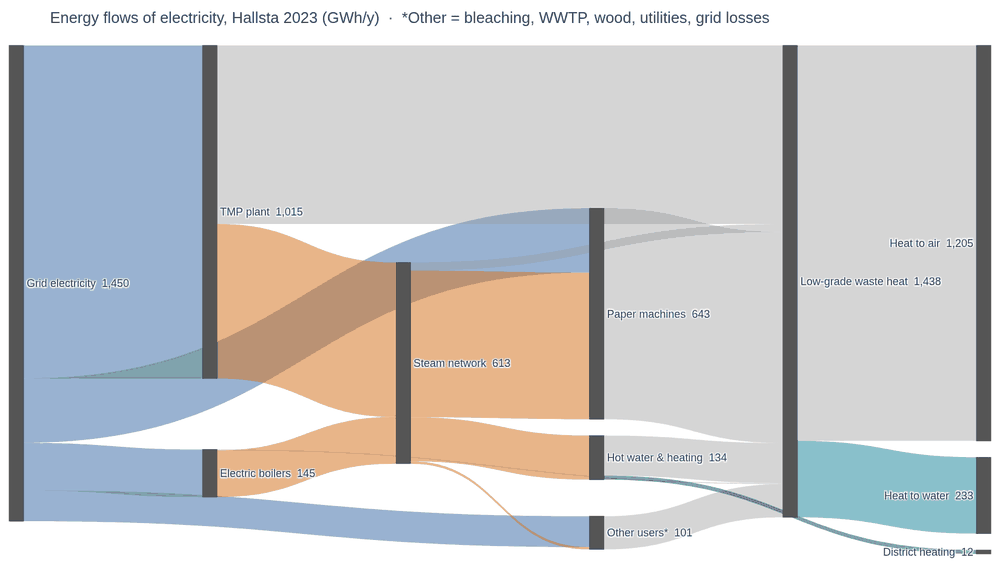

In [16]:
other_el = b['el_bleach'] + b['el_wwtp'] + b['el_wood'] + b['el_util'] + b['el_dist']
links_E = pd.DataFrame([
 ('Grid electricity','TMP plant',b['el_TMP']), ('Grid electricity','Electric boilers',b['el_EB']),
 ('Grid electricity','Paper machines',b['el_PM']), ('Grid electricity','Other users*',other_el),
 ('TMP plant','Steam network',b['st_rec']), ('Electric boilers','Steam network',b['st_EB']),
 ('TMP plant','Low-grade waste heat',b['TMP_waste']), ('Electric boilers','Low-grade waste heat',b['loss_EB']),
 ('Steam network','Paper machines',b['st_PM']), ('Steam network','Hot water & heating',b['st_HW']),
 ('Steam network','Other users*',b['st_wood']), ('Steam network','Low-grade waste heat',b['st_loss']),
 ('Paper machines','Low-grade waste heat',b['PM_waste']), ('Other users*','Low-grade waste heat',other_el+b['st_wood']),
 ('Hot water & heating','District heating',b['sink_DH']), ('Hot water & heating','Low-grade waste heat',b['st_HW']-b['sink_DH']),
 ('Low-grade waste heat','Heat to air',b['sink_air']), ('Low-grade waste heat','Heat to water',b['sink_water'])],
 columns=['source','target','GWh/y'])

def sankey(links, title, colors):
    nodes = list(dict.fromkeys(list(links.source) + list(links.target))); ix = {n:i for i,n in enumerate(nodes)}
    tot = {n: max(links[links.source==n]['GWh/y'].sum(), links[links.target==n]['GWh/y'].sum()) for n in nodes}
    fig = go.Figure(go.Sankey(valueformat=',.0f', valuesuffix=' GWh/y',
        node=dict(label=[f'{n}  {tot[n]:,.0f}' for n in nodes], pad=18, thickness=16, color='#555'),
        link=dict(source=links.source.map(ix), target=links.target.map(ix), value=links['GWh/y'],
                  color=[colors(s, t) for s, t in zip(links.source, links.target)])))
    fig.update_layout(title=title, height=620, font_size=12, margin=dict(l=10, r=10, t=50, b=10))
    return fig

def col_E(s, t):
    if s == 'Grid electricity': return 'rgba(52,101,164,0.5)'
    if t == 'Steam network' or s == 'Steam network' and t != 'Low-grade waste heat': return 'rgba(214,120,40,0.55)'
    if t == 'District heating': return 'rgba(50,150,80,0.7)'
    if t == 'Heat to water': return 'rgba(40,140,160,0.55)'
    return 'rgba(150,150,150,0.4)'
display(links_E)
fig_E = sankey(links_E, 'Energy flows of electricity, Hallsta 2023 (GWh/y)  ·  *Other = bleaching, WWTP, wood, utilities, grid losses', col_E)
fig_E.write_image(OUT / 'sankey_energy.png', width=1100, height=620, scale=1.5)
display(Image(OUT / 'sankey_energy.png'))   # static, shows on GitHub
# fig_E.show()   # uncomment for the interactive version in Jupyter

## 6. Exergy analysis and hotspots
**Intuition.** 1 kWh of electricity can run a motor. 1 kWh of 30 °C water can do almost nothing. Both are "1 kWh of energy", but their *usefulness* differs hugely. Exergy measures usefulness. Looking only at energy says "everything ends as heat, all equal". Looking at exergy shows *where the useful part is thrown away* (that is **destroyed exergy**).

**Formulas.** Exergy per unit of heat released from temperature $T_h$ down to the surroundings $T_0$ (in kelvin):

$$\frac{Ex}{Q} = 1 - \frac{T_0\,\ln(T_h/T_0)}{T_h - T_0}$$

For steam: $ex = \Delta h - T_0\,\Delta s$. Each process gets one balance: **Ex_in = Ex_useful + Ex_waste + Ex_destroyed**. Efficiency $\psi = Ex_{useful}/Ex_{in}$.

**Worked intuition.** An electric boiler turns 1 kWh of pure-exergy electricity into steam. Its *energy* efficiency is ~98%, but the steam only holds ~30% of that exergy. So 70% of the quality is gone even though almost no energy was "lost".

In [17]:
pd.Series({'Electricity': 1.0, 'Steam 3.4 bar → 90 °C condensate': b['fx_steam'], 'District heat 85/45 °C': b['f_DH'],
           'Unrecovered TMP heat, 80 °C': b['f_TMPw'], 'Hot water, 60 °C': b['f_HW'], 'PM waste heat, 55 °C': b['f_PMw'],
           'Effluent, 35 °C': b['f_eff']}, name='exergy per unit energy').to_frame().style.format('{:.3f}')

,exergy per unit energy
Electricity,1.000
Steam 3.4 bar → 90 °C condensate,0.315
District heat 85/45 °C,0.171
"Unrecovered TMP heat, 80 °C",0.111
"Hot water, 60 °C",0.084
"PM waste heat, 55 °C",0.077
"Effluent, 35 °C",0.047


In [18]:
energy_loss = {'TMP plant': b['TMP_waste'], 'Paper machines': b['PM_waste'], 'Electric boilers': b['loss_EB'],
               'Hot water & heating': b['st_HW']-b['sink_DH'], 'Steam network': b['st_loss'], 'Bleaching': b['el_bleach'],
               'WWTP': b['el_wwtp'], 'Wood handling': b['el_wood']+b['st_wood'], 'Utilities & other': b['el_util'],
               'Internal grid losses': b['el_dist']}
HX = pd.DataFrame({'Exergy in': [b[f'Xin|{p}'] for p in PROCS], 'Useful out': [b[f'Xuse|{p}'] for p in PROCS],
                   'Waste out': [b[f'Xwaste|{p}'] for p in PROCS], 'Destroyed': [b[f'Xdest|{p}'] for p in PROCS],
                   'ψ': [b[f'psi|{p}'] for p in PROCS], 'Improvement potential': [b[f'IP|{p}'] for p in PROCS],
                   'Energy view: heat lost': [energy_loss[p] for p in PROCS]}, index=PROCS)
HX['Energy rank'] = HX['Energy view: heat lost'].rank(ascending=False).astype(int)
HX['Exergy rank'] = HX['Destroyed'].rank(ascending=False).astype(int)
HX.sort_values('Destroyed', ascending=False).style.format({c: '{:,.1f}' for c in HX.columns if c not in ('ψ','Energy rank','Exergy rank')} | {'ψ': '{:.0%}'})

,Exergy in,Useful out,Waste out,Destroyed,ψ,Improvement potential,Energy view: heat lost,Energy rank,Exergy rank
TMP plant,"1,015.0",148.1,60.6,806.3,15%,740.4,544.3,2,1
Paper machines,336.6,0.0,49.5,287.1,0%,336.6,643.0,1,2
Electric boilers,145.0,44.7,0.0,100.3,31%,69.3,2.8,10,3
Hot water & heating,42.2,11.3,0.0,30.9,27%,22.7,122.3,3,4
WWTP,21.9,0.0,0.0,21.9,0%,21.9,21.9,6,5
Bleaching,21.6,0.0,0.0,21.6,0%,21.6,21.6,7,6
Wood handling,20.2,0.0,0.0,20.2,0%,20.2,25.1,4,7
Utilities & other,18.1,0.0,0.0,18.1,0%,18.1,18.1,8,8
Internal grid losses,14.5,0.0,0.0,14.5,0%,14.5,14.5,9,9
Steam network,192.8,185.1,0.0,7.7,96%,0.3,24.5,5,10


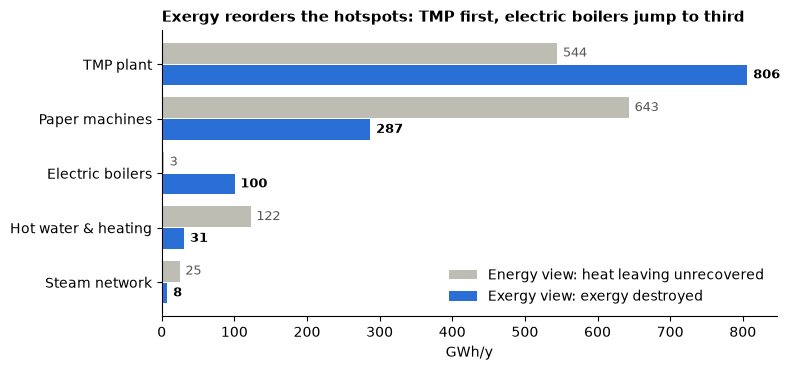

In [19]:
top = ['TMP plant','Paper machines','Electric boilers','Hot water & heating','Steam network']
fig, ax = plt.subplots(figsize=(8, 3.8)); y = np.arange(len(top))
ax.barh(y-0.2, HX.loc[top,'Energy view: heat lost'], 0.38, color='#bdbdb3', label='Energy view: heat leaving unrecovered')
ax.barh(y+0.2, HX.loc[top,'Destroyed'], 0.38, color='#2a6fd6', label='Exergy view: exergy destroyed')
for i, p in enumerate(top):
    ax.text(HX.loc[p,'Energy view: heat lost']+8, i-0.2, f"{HX.loc[p,'Energy view: heat lost']:,.0f}", va='center', fontsize=9, color='#555')
    ax.text(HX.loc[p,'Destroyed']+8, i+0.2, f"{HX.loc[p,'Destroyed']:,.0f}", va='center', fontsize=9, fontweight='bold')
ax.set_yticks(y, top); ax.invert_yaxis(); ax.set_xlabel('GWh/y'); ax.legend(frameon=False, loc='lower right')
ax.set_title('Exergy reorders the hotspots: TMP first, electric boilers jump to third', loc='left', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

In [20]:
print(f"Total exergy destroyed : {b['Xdest_total']:,.0f} GWh/y ({b['Xdest_total']/E:.0%} of input)")
print(f"Electric boilers       : energy efficiency {b['eff_EB']:.0%}, exergy efficiency {b['psi|Electric boilers']:.0%}")
print(f"Lever 1 – TMP to 2,150 kWh/t : {b['gap_SEC']:.0f} GWh/y gross, {b['gap_SEC_net']:.0f} GWh/y net of lost steam")
print(f"Lever 2 – 90% steam from TMP : {b['save_rec90']:.0f} GWh/y")

Total exergy destroyed : 1,329 GWh/y (92% of input)
Electric boilers       : energy efficiency 98%, exergy efficiency 31%
Lever 1 – TMP to 2,150 kWh/t : 108 GWh/y gross, 57 GWh/y net of lost steam
Lever 2 – 90% steam from TMP : 83 GWh/y


## 7. Robustness: Monte Carlo, sensitivity and scenarios
**Intuition.** Our inputs are estimates. If we are told "TMP share is 70%", the truth could be 65 or 75. Monte Carlo rolls the dice: draw a plausible value for every input, run the model, store the result, repeat 10,000 times. The spread of results shows how much we should trust the conclusion. If the ranking of hotspots barely changes across all runs, the conclusion is **robust**.

**Step 7a: turn data quality into uncertainty ranges.** The quality class from section 1 decides how wide each range is. Class A numbers get narrow ranges (a few %), class C numbers wide ones. Where 2019 and 2025 disagree, the 2019 value marks the far end of the triangle.

In [21]:
DIST = {  # name: (distribution, a, b, c)  — normal: mean, sd · triangular: low, mode, high · uniform: low, high
 'E_tot': ('norm', 1450, 14.5, None), 'pulp_t': ('norm', 421883, 4218.83, None), 'paper_t': ('norm', 444494, 4444.94, None),
 'DH_export': ('norm', 11.877, 0.59385, None), 'V_wwtp': ('norm', BASE['V_wwtp'], 0.05*BASE['V_wwtp'], None),
 'V_ff': ('norm', BASE['V_ff'], 0.10*BASE['V_ff'], None),
 'sh_TMP': ('tri', 0.65, 0.70, 0.75), 'sh_PM': ('tri', 0.12, 0.15, 0.22), 'sh_EB': ('tri', 0.05, 0.10, 0.12), 'sh_OTH': ('tri', 0.02, 0.05, 0.08),
 'P_wood': ('tri', 2.0, 2.5, 3.0), 'P_bleach': ('tri', 2.4, 3.0, 3.6), 'P_wwtp': ('tri', 2.0, 2.5, 3.0), 'aux_TMP': ('tri', 120, 150, 180),
 'm_rec': ('tri', 85, 100, 115), 'y_EB': ('tri', 1.45, 1.50, 1.53), 'm_PM': ('uni', 80, 110, None), 'm_wood': ('tri', 1.2, 1.5, 1.8),
 'PM11_frac': ('uni', 0.525, 0.66, None), 'h_prod': ('tri', 6800, 7200, 7600), 'f_dist': ('uni', 0.005, 0.02, None),
 'f_steamloss': ('uni', 0.02, 0.06, None), 'p_steam': ('uni', 3.3e5, 3.6e5, None), 'T_cond': ('uni', 80, 100, None),
 'T_TMPwaste': ('uni', 70, 100, None), 'T_PMwaste': ('uni', 45, 65, None), 'T_HW': ('uni', 50, 70, None),
 'T_eff': ('uni', 28, 40, None), 'T_ff': ('uni', 20, 40, None)}
pd.DataFrame(DIST, index=['distribution','a','b','c']).T

,distribution,a,b,c
E_tot,norm,1450,14.50,None
pulp_t,norm,421883,"4,218.83",None
paper_t,norm,444494,"4,444.94",None
DH_export,norm,11.88,0.59,None
V_wwtp,norm,6679500,"333,975.00",None
V_ff,norm,609361,"60,936.10",None
sh_TMP,tri,0.65,0.70,0.75
sh_PM,tri,0.12,0.15,0.22
sh_EB,tri,0.05,0.10,0.12
sh_OTH,tri,0.02,0.05,0.08


**Step 7b: run 10,000 times.** Every run draws a value for each input, runs the same `run()` function and stores all results. Shares are rescaled to 100% inside `run()`, so every run is still a closed energy balance. A run is flagged inconsistent if the TMP share of steam falls outside Holmen's 70–90% or the steam residual goes negative.

In [22]:
# 'DIST' is imported from src/hallsta_mfa/model.py (same table as above)
rng = np.random.default_rng(2023); N = 10_000   # fixed seed: same numbers on every run
S = {}
for k, (d, a, bb, c) in DIST.items():
    S[k] = rng.normal(a, bb, N) if d == 'norm' else (rng.triangular(a, bb, c, N) if d == 'tri' else rng.uniform(a, bb, N))
P = dict(BASE); P.update(S)
Y = pd.DataFrame({k: v for k, v in run(P).items() if np.ndim(v) == 1})
X = pd.DataFrame(S)
ok = Y.rec_ratio.between(0.70, 0.90) & (Y.st_HW >= 0)
print(f'{N:,} runs done. Consistent with Holmen data: {ok.mean():.1%}')

10,000 runs done. Consistent with Holmen data: 99.2%


**Step 7b result: percentiles.** `base` is the single run with best-guess inputs. P5-P95 is the range containing 90% of runs.

In [23]:
keys = {'el_TMP':'Electricity TMP','el_PM':'Electricity paper machines','el_EB':'Electricity electric boilers',
        'st_rec':'Recovered TMP steam','rec_ratio':'Share of steam from TMP','st_HW':'Steam residual (hot water, venting)',
        'sink_water':'Heat to water','sink_air':'Heat to air','SEC_TMP':'TMP kWh/t',
        'Xdest|TMP plant':'Exergy destroyed TMP','Xdest|Paper machines':'Exergy destroyed PM',
        'Xdest|Electric boilers':'Exergy destroyed boilers','Xdest_total':'Exergy destroyed total',
        'save_rec90':'Saving, 90% steam from TMP','gap_SEC':'Saving, TMP at 2,150 kWh/t (gross)'}
MC = pd.DataFrame({'base': [b[k] for k in keys], 'P5': [Y[k].quantile(.05) for k in keys],
                   'P50': [Y[k].median() for k in keys], 'P95': [Y[k].quantile(.95) for k in keys]}, index=keys.values())
MC

,base,P5,P50,P95
Electricity TMP,"1,015.00",959.90,"1,011.69","1,064.38"
Electricity paper machines,195.90,174.64,212.21,260.50
Electricity electric boilers,145.00,93.32,132.60,159.42
Recovered TMP steam,470.68,419.87,470.33,521.89
Share of steam from TMP,0.77,0.75,0.79,0.84
"Steam residual (hot water, venting)",134.14,33.28,120.03,205.69
Heat to water,232.87,180.21,224.83,273.19
Heat to air,"1,205.25","1,159.06","1,213.67","1,264.90"
TMP kWh/t,"2,405.88","2,270.76","2,396.82","2,526.68"
Exergy destroyed TMP,806.30,752.01,799.29,847.96


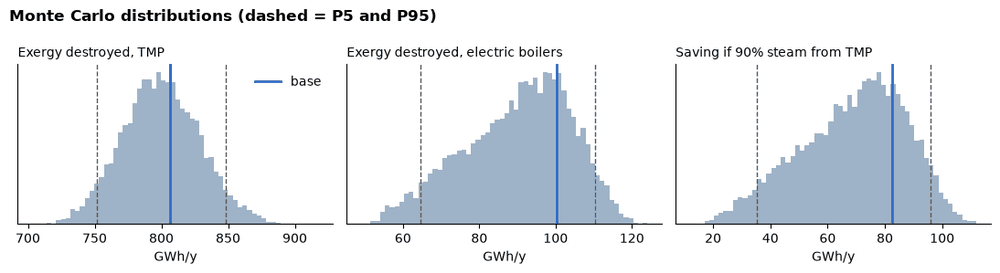

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, k, t in zip(axes, ['Xdest|TMP plant','Xdest|Electric boilers','save_rec90'],
                    ['Exergy destroyed, TMP','Exergy destroyed, electric boilers','Saving if 90% steam from TMP']):
    ax.hist(Y[k], bins=60, color='#9fb3c8'); ax.axvline(b[k], color='#2a6fd6', lw=2, label='base')
    for q in (.05, .95): ax.axvline(Y[k].quantile(q), color='#555', ls='--', lw=1)
    ax.set_title(t, fontsize=10, loc='left'); ax.set_xlabel('GWh/y'); ax.set_yticks([])
axes[0].legend(frameon=False); fig.suptitle('Monte Carlo distributions (dashed = P5 and P95)', x=0.01, ha='left', fontweight='bold')
plt.tight_layout(); plt.show()

**Step 7c: is the hotspot ranking stable?** For each run, rank the processes by exergy destroyed and count how often each lands in each position.

In [25]:
D = Y[[f'Xdest|{p}' for p in PROCS]]; D.columns = PROCS
rk = D.rank(axis=1, ascending=False)
stab = pd.DataFrame({f'rank {r}': (rk == r).mean() for r in range(1, 5)})
display(stab.style.format('{:.1%}'))
top3 = ((rk['TMP plant']==1) & (rk['Paper machines']==2) & (rk['Electric boilers']==3)).mean()
print(f'TMP > paper machines > electric boilers in {top3:.2%} of runs')
print(f"Energy view: paper machines lose more heat than TMP in {(Y.PM_waste > Y.TMP_waste).mean():.1%} of runs")

,rank 1,rank 2,rank 3,rank 4
TMP plant,100.0%,0.0%,0.0%,0.0%
Paper machines,0.0%,100.0%,0.0%,0.0%
Electric boilers,0.0%,0.0%,100.0%,0.0%
Hot water & heating,0.0%,0.0%,0.0%,52.8%
Steam network,0.0%,0.0%,0.0%,0.0%
Bleaching,0.0%,0.0%,0.0%,9.5%
WWTP,0.0%,0.0%,0.0%,6.8%
Wood handling,0.0%,0.0%,0.0%,1.1%
Utilities & other,0.0%,0.0%,0.0%,21.7%
Internal grid losses,0.0%,0.0%,0.0%,8.1%


TMP > paper machines > electric boilers in 99.96% of runs
Energy view: paper machines lose more heat than TMP in 94.7% of runs


**Step 7d: which inputs drive the results?** *Intuition:* if an input and a result rise and fall together across the 10,000 runs, that input matters. Spearman ρ measures this from -1 to +1. Red/blue cells with |ρ| above 0.3 are the important drivers. Only rows with at least one strong cell are shown.

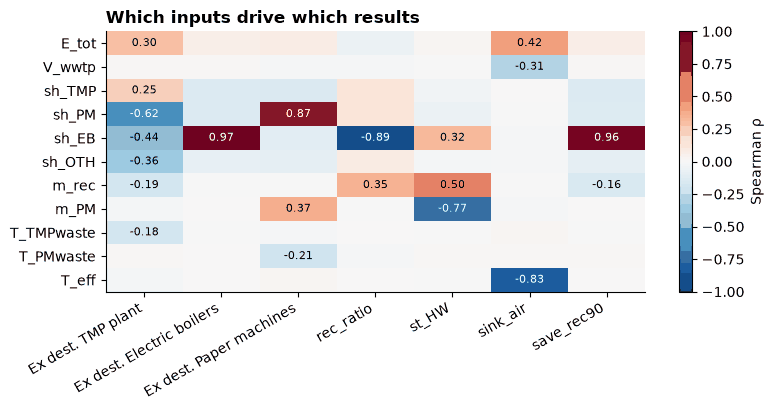

In [26]:
outs = ['Xdest|TMP plant','Xdest|Electric boilers','Xdest|Paper machines','rec_ratio','st_HW','sink_air','save_rec90']
SP = pd.DataFrame({o: [spearmanr(X[k], Y[o])[0] for k in DIST] for o in outs}, index=list(DIST))
SP = SP[(SP.abs() >= 0.15).any(axis=1)]
fig, ax = plt.subplots(figsize=(8, 4.2))
im = ax.imshow(SP.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(outs)), [o.replace('Xdest|', 'Ex dest. ') for o in outs], rotation=30, ha='right'); ax.set_yticks(range(len(SP)), SP.index)
for i in range(SP.shape[0]):
    for j in range(SP.shape[1]):
        v = SP.values[i, j]
        if abs(v) >= 0.15: ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(v) > 0.6 else 'black')
plt.colorbar(im, ax=ax, label='Spearman ρ'); ax.set_title('Which inputs drive which results', loc='left', fontweight='bold'); plt.tight_layout(); plt.show()

**Tornado chart.** Change one input at a time to its low and high end (everything else at base) and see how far the decision metric swings. Longest bars = biggest levers.

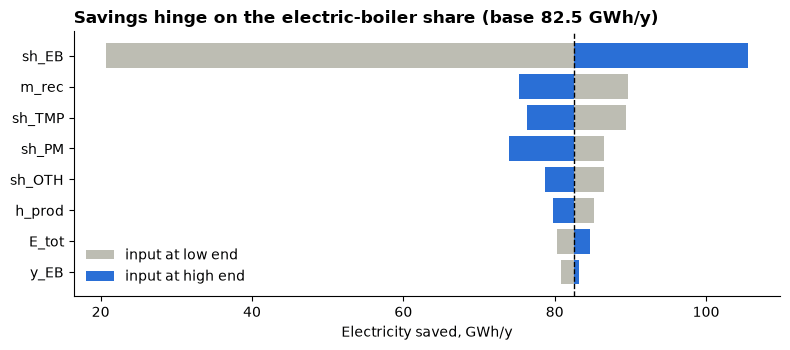

In [27]:
# One-at-a-time tornado for the decision metric: saving if 90 % of steam came from TMP
def ends(k):
    d, a, bb, c = DIST[k]
    return (a - 1.645*bb, a + 1.645*bb) if d == 'norm' else ((a, c) if d == 'tri' else (a, bb))
rows = []
for k in DIST:
    lo, hi = ends(k)
    rows.append((k, run({**BASE, k: lo})['save_rec90'], run({**BASE, k: hi})['save_rec90']))
T = pd.DataFrame(rows, columns=['input','at low','at high']).assign(swing=lambda d: (d['at high']-d['at low']).abs()).nlargest(8, 'swing')[::-1]
fig, ax = plt.subplots(figsize=(8, 3.6)); base_v = b['save_rec90']
ax.barh(T.input, T['at low']-base_v, left=base_v, color='#bdbdb3', label='input at low end')
ax.barh(T.input, T['at high']-base_v, left=base_v, color='#2a6fd6', label='input at high end')
ax.axvline(base_v, color='k', ls='--', lw=1); ax.set_xlabel('Electricity saved, GWh/y'); ax.legend(frameon=False, loc='lower left')
ax.set_title(f'Savings hinge on the electric-boiler share (base {base_v:.1f} GWh/y)', loc='left', fontweight='bold'); plt.tight_layout(); plt.show()

**Step 7e: scenarios.** Discrete "what if" cases that a range cannot express (for example, "use the 2019 electricity split"). Each scenario changes a few inputs and re-runs `run()`.

In [28]:
sc = {'S0 Base': {}, 'S1 2019 split': dict(sh_TMP=0.72*0.9625, sh_PM=0.22*0.9625, sh_EB=0.06*0.9625, sh_OTH=0.0375),
      'S2 T0 = 25 °C': dict(T0=25.0), 'S3 PM steam 110 t/h': dict(m_PM=110.0), 'S4 stress: 85 t/h rec. + 110 t/h PM': dict(m_rec=85.0, m_PM=110.0)}
SC = {}
for n, ch in sc.items():
    r_ = run({**BASE, **ch})
    order = sorted(PROCS, key=lambda p: r_[f'Xdest|{p}'], reverse=True)[:3]
    SC[n] = {'Boiler electricity': r_['el_EB'], 'Steam share from TMP': f"{r_['rec_ratio']:.0%}", 'Steam residual': r_['st_HW'],
             'Ex destroyed TMP': r_['Xdest|TMP plant'], 'Ex destroyed boilers': r_['Xdest|Electric boilers'],
             'Saving 90% rec.': r_['save_rec90'], 'Top 3': ' > '.join(order)}
pd.DataFrame(SC).T

,Boiler electricity,Steam share from TMP,Steam residual,Ex destroyed TMP,Ex destroyed boilers,Saving 90% rec.,Top 3
S0 Base,145.00,77%,134.14,806.30,100.26,82.50,TMP plant > Paper machines > Electric boilers
S1 2019 split,83.74,85%,76.47,797.28,57.90,27.36,TMP plant > Paper machines > Electric boilers
S2 T0 = 25 °C,145.00,77%,134.14,842.85,106.52,82.50,TMP plant > Paper machines > Electric boilers
S3 PM steam 110 t/h,145.00,77%,63.54,806.30,100.26,82.50,TMP plant > Paper machines > Electric boilers
S4 stress: 85 t/h rec. + 110 t/h PM,145.00,74%,-4.24,820.66,100.26,89.70,TMP plant > Paper machines > Electric boilers


S4 gives a negative steam residual. Those two data points cannot both be true while the boilers use 145 GWh, which is a useful plausibility check on Holmen's ranges. The top three stay in the same order in every scenario.

## Conclusions

1. **Flows:** TMP 70% · paper machines 13.5% · electric boilers 10% · others 6.5%. 77% of steam comes from TMP heat recovery. 83% of the energy leaves as heat to air, 16% to water and 0.8% as district heat.
2. **Hotspots:** energy points at the paper machines and TMP. Exergy points at TMP refining, the paper machines and the electric boilers, which are 98% energy-efficient but only 31% exergy-efficient.
3. **Robustness:** the ranking holds in 99.96% of runs and in all scenarios. The boiler flow is the main uncertainty.

In [29]:
# Export results for the report / workbook
MC.to_csv(OUT / 'nb_mc_summary.csv'); HX.to_csv(OUT / 'nb_exergy_hotspots.csv'); links_E.to_csv(OUT / 'nb_sankey_energy_links.csv', index=False)
print('Saved to', OUT)

Saved to outputs
